In [57]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures as SklearnPolynomialFeatures

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Загрузка данных (колонка id становится индексом)
train = pd.read_csv('train.csv', index_col='index')
test = pd.read_csv('test.csv', index_col='index')

# 2. Разделение на признаки и таргет
X_train = train.drop(columns=['target'])
y_train = train['target']
X_test = test

In [58]:
# 3. Обучение простейшей линейной модели


lr_pipeline = make_pipeline(
    SklearnPolynomialFeatures(degree=2),
    Lasso(alpha=1)
)

lr_pipeline.fit(X_train, y_train)

print("r2:", lr_pipeline.score(X_train, y_train))

r2: 0.9610677833904351


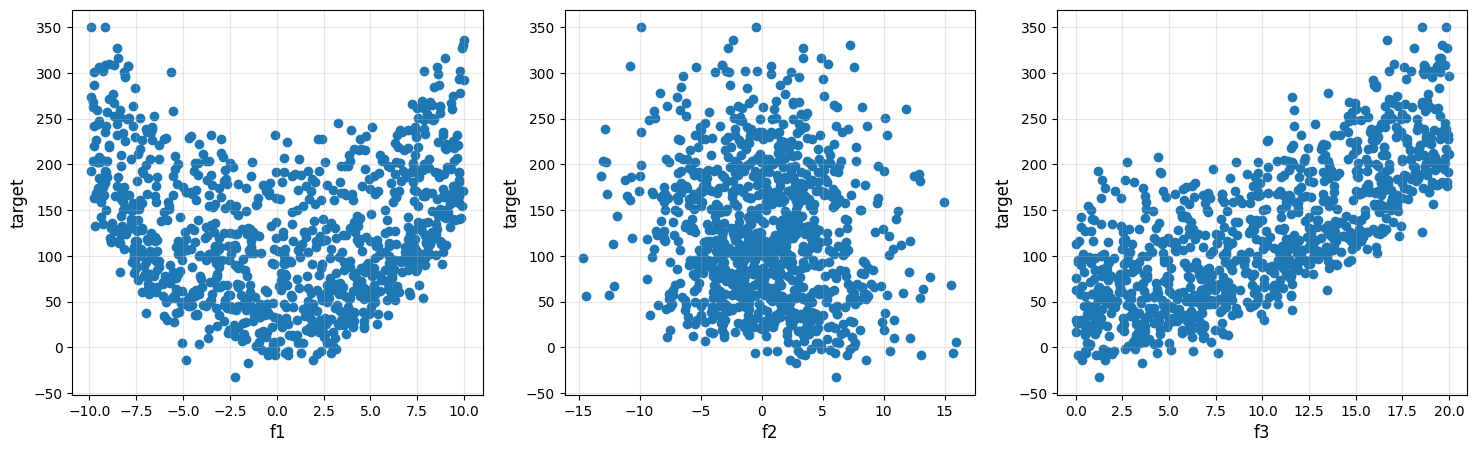

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc1 = axes[0].scatter(train['f1'], train['target'])
axes[0].set_xlabel('f1', fontsize=12)
axes[0].set_ylabel('target', fontsize=12)
axes[0].grid(True, alpha=0.3)

sc2 = axes[1].scatter(train['f2'], train['target'])
axes[1].set_xlabel('f2', fontsize=12)
axes[1].set_ylabel('target', fontsize=12)
axes[1].grid(True, alpha=0.3)


sc3 = axes[2].scatter(train['f3'], train['target'])
axes[2].set_xlabel('f3', fontsize=12)
axes[2].set_ylabel('target', fontsize=12)
axes[2].grid(True, alpha=0.3)

In [60]:


target_mean = train['target'].mean()
target_std = train['target'].std()
target_75_percentile = train['target'].quantile(0.75)

print(f"\n{target_mean:.2f},{target_std:.2f},{target_75_percentile:.2f}")




124.91,76.02,178.40


In [61]:
# 4. Предсказание на тестовой выборке
predictions = lr_pipeline.predict(X_test)

# 5. Формирование файла для отправки
submission = pd.DataFrame({
    'index': test.index, 
    'target': predictions
})
submission.to_csv('submission.csv', index=False)

print("Бейзлайн обучен. Предсказания сохранены в submission.csv")

Бейзлайн обучен. Предсказания сохранены в submission.csv
